In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import pandas as pd

from src.data_loader import get_prices
from src.features import calculate_returns
from src.portfolio import portfolio_return, portolio_volatility, sharpe_ratio

In [3]:
tickers = ["AAPL", "TSLA", "SPY"]

prices = get_prices(tickers)
returns = calculate_returns(prices)

[*********************100%***********************]  3 of 3 completed


In [4]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

In [5]:
num_portfolios = 5000
results = []

for _ in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights = weights / np.sum(weights)

    r = portfolio_return(weights, mean_returns)
    v = portolio_volatility(weights, cov_matrix)
    s = r / v

    results.append((r, v, s))

In [6]:
results_df = pd.DataFrame(results, columns=["Return", "Volatility", "Sharpe"])

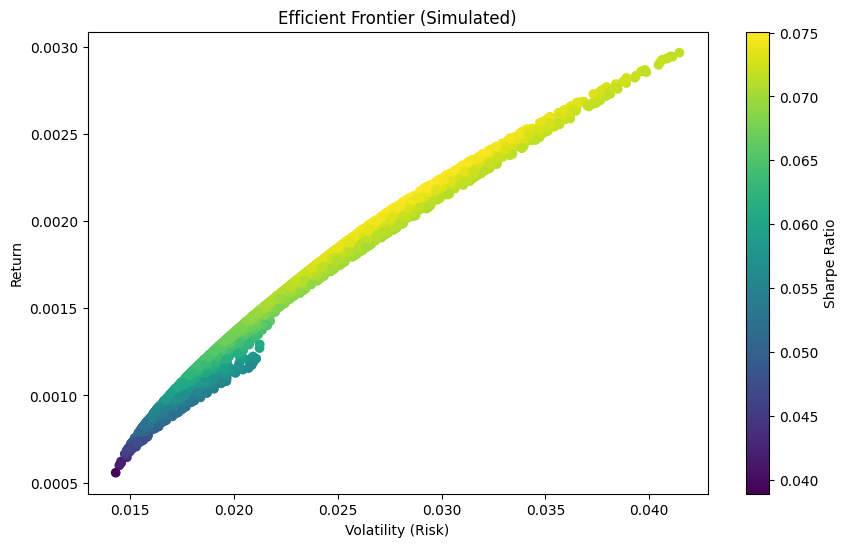

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(results_df["Volatility"], results_df["Return"], c=results_df["Sharpe"], cmap="viridis")

plt.xlabel("Volatility (Risk)")
plt.ylabel("Return")
plt.title("Efficient Frontier (Simulated)")
plt.colorbar(label="Sharpe Ratio")
plt.show()

In [8]:
best_idx = results_df["Sharpe"].idxmax()
best_portfolio = results_df.iloc[best_idx]

best_portfolio

Return        0.002125
Volatility    0.028313
Sharpe        0.075067
Name: 4535, dtype: float64